In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [13]:
# Prevent the width from wrapping to the next line
from xml.parsers.expat import errors


pd.set_option('display.expand_frame_repr', False)

# Read the data from the CSV file
df = pd.read_csv('data/Health Care_Patient_survey_source.csv')

# Clean the data by removing rows with missing values in the 'Number of Completed Surveys' column
df_clean = df.dropna(subset=['Number of Completed Surveys'])

# Convert the 'Number of Completed Surveys' column to numeric, coercing errors to NaN
df_clean['Number of Completed Surveys'] = pd.to_numeric(df_clean['Number of Completed Surveys'], errors='coerce')

# Print the first few rows of the DataFrame to understand its structure
print(df_clean.head())

   Provider ID                     Hospital Name                 Address    City State  ZIP Code County Name  Phone Number            Measure ID                                           Question  ...  Answer Percent Answer Percent Footnote Linear Mean Value Number of Completed Surveys Number of Completed Surveys Footnote Survey Response Rate Percent  Survey Response Rate Percent Footnote Measure Start Date Measure End Date                                           Location
0        10001  SOUTHEAST ALABAMA MEDICAL CENTER  1108 ROSS CLARK CIRCLE  DOTHAN    AL     36301     HOUSTON    3347938701       H_CLEAN_HSP_A_P  Patients who reported that their room and bath...  ...              63                     NaN    Not Applicable                       506.0                                  NaN                           21                                    NaN           07/01/17       06/30/2018  1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21...
1        10001  SOUTHEAST ALABAMA MEDICAL 

In [ ]:
# Each hospital row repeats the survey count per measure — take the unique value per hospital
surveys_by_hospital = (
    df_clean.groupby(['Provider ID', 'Hospital Name'])['Number of Completed Surveys'].first()
    .reset_index()
    .rename(columns={'Number of Completed Surveys': 'Completed Surveys'})
    .sort_values('Provider ID', ascending=True)
    .reset_index(drop=True))


print(f"Total hospitals: {len(surveys_by_hospital)}")
print()
print(surveys_by_hospital.head(10))

Total hospitals: 700

   Provider ID                     Hospital Name  Completed Surveys
0        10001  Southeast Alabama Medical Center              506.0
1        10005     Marshall Medical Center South             1135.0
2        10006    Eliza Coffee Memorial Hospital              579.0
3        10007          Mizell Memorial Hospital              185.0
4        10008       Crenshaw Community Hospital               63.0
5        10011                 St Vincent'S East             2193.0
6        10012    Dekalb Regional Medical Center              513.0
7        10016     Shelby Baptist Medical Center             1103.0
8        10018             Callahan Eye Hospital               38.0
9        10019    Helen Keller Memorial Hospital              578.0


In [ ]:

# ── 1. Drop footnote columns (long explanatory text, not analytical value) ──
footnote_cols = [
    'Patient Survey Star Rating Footnote',
    'Answer Percent Footnote',
    'Number of Completed Surveys Footnote',
    'Survey Response Rate Percent Footnote',
]
df_clean = df_clean.drop(columns=footnote_cols)

# ── 2. Standardise "Not Applicable" → NaN across all object columns ──────────
df_clean = df_clean.replace('Not Applicable', pd.NA)

# ── 3. Convert remaining numeric columns to proper types ──────────────────────
for col in ['Patient Survey Star Rating', 'Answer Percent', 'Linear Mean Value', 'Survey Response Rate Percent']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# ── 4. Convert date columns to datetime ──────────────────────────────────────
df_clean['Measure Start Date'] = pd.to_datetime(df_clean['Measure Start Date'], errors='coerce')
df_clean['Measure End Date']   = pd.to_datetime(df_clean['Measure End Date'],   errors='coerce')



# ── 8. Fill missing County Name ───────────────────────────────────────────────
df_clean['County Name'] = df_clean['County Name'].fillna('Unknown')

# ── 9. Title-case text fields ─────────────────────────────────────────────────
for col in ['Hospital Name', 'Address', 'City', 'County Name']:
    df_clean[col] = df_clean[col].str.title()

# ── Summary ───────────────────────────────────────────────────────────────────
print("Shape after cleaning:", df_clean.shape)
print()
print("Dtypes:")
print(df_clean.dtypes)
print()
print("Remaining nulls:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print()
print(df_clean.head(3).to_string())


Shape after cleaning: (34999, 19)

Dtypes:
Provider ID                              int64
Hospital Name                              str
Address                                    str
City                                       str
State                                      str
ZIP Code                                 int64
County Name                                str
Phone Number                             int64
Measure ID                                 str
Question                                   str
Answer Description                         str
Patient Survey Star Rating             float64
Answer Percent                         float64
Linear Mean Value                      float64
Number of Completed Surveys            float64
Survey Response Rate Percent           float64
Measure Start Date              datetime64[us]
Measure End Date                datetime64[us]
Location                                   str
dtype: object

Remaining nulls:
Patient Survey Star Rating      

Survey Response Rate (%) by Measure ID:
                           Hospitals  Mean  Median  Min   Max
Measure ID                                                   
H_STAR_RATING                    618  23.8    23.0  7.0  60.0
H_COMP_6_STAR_RATING             619  23.8    23.0  7.0  60.0
H_COMP_6_Y_P                     619  23.8    23.0  7.0  60.0
H_COMP_7_A                       619  23.8    23.0  7.0  60.0
H_COMP_7_D_SD                    619  23.8    23.0  7.0  60.0
H_COMP_7_LINEAR_SCORE            619  23.8    23.0  7.0  60.0
H_COMP_7_SA                      619  23.8    23.0  7.0  60.0
H_COMP_7_STAR_RATING             619  23.8    23.0  7.0  60.0
H_HSP_RATING_0_6                 619  23.8    23.0  7.0  60.0
H_HSP_RATING_7_8                 619  23.8    23.0  7.0  60.0
H_HSP_RATING_9_10                619  23.8    23.0  7.0  60.0
H_HSP_RATING_LINEAR_SCORE        619  23.8    23.0  7.0  60.0
H_HSP_RATING_STAR_RATING         619  23.8    23.0  7.0  60.0
H_QUIET_HSP_A_P               

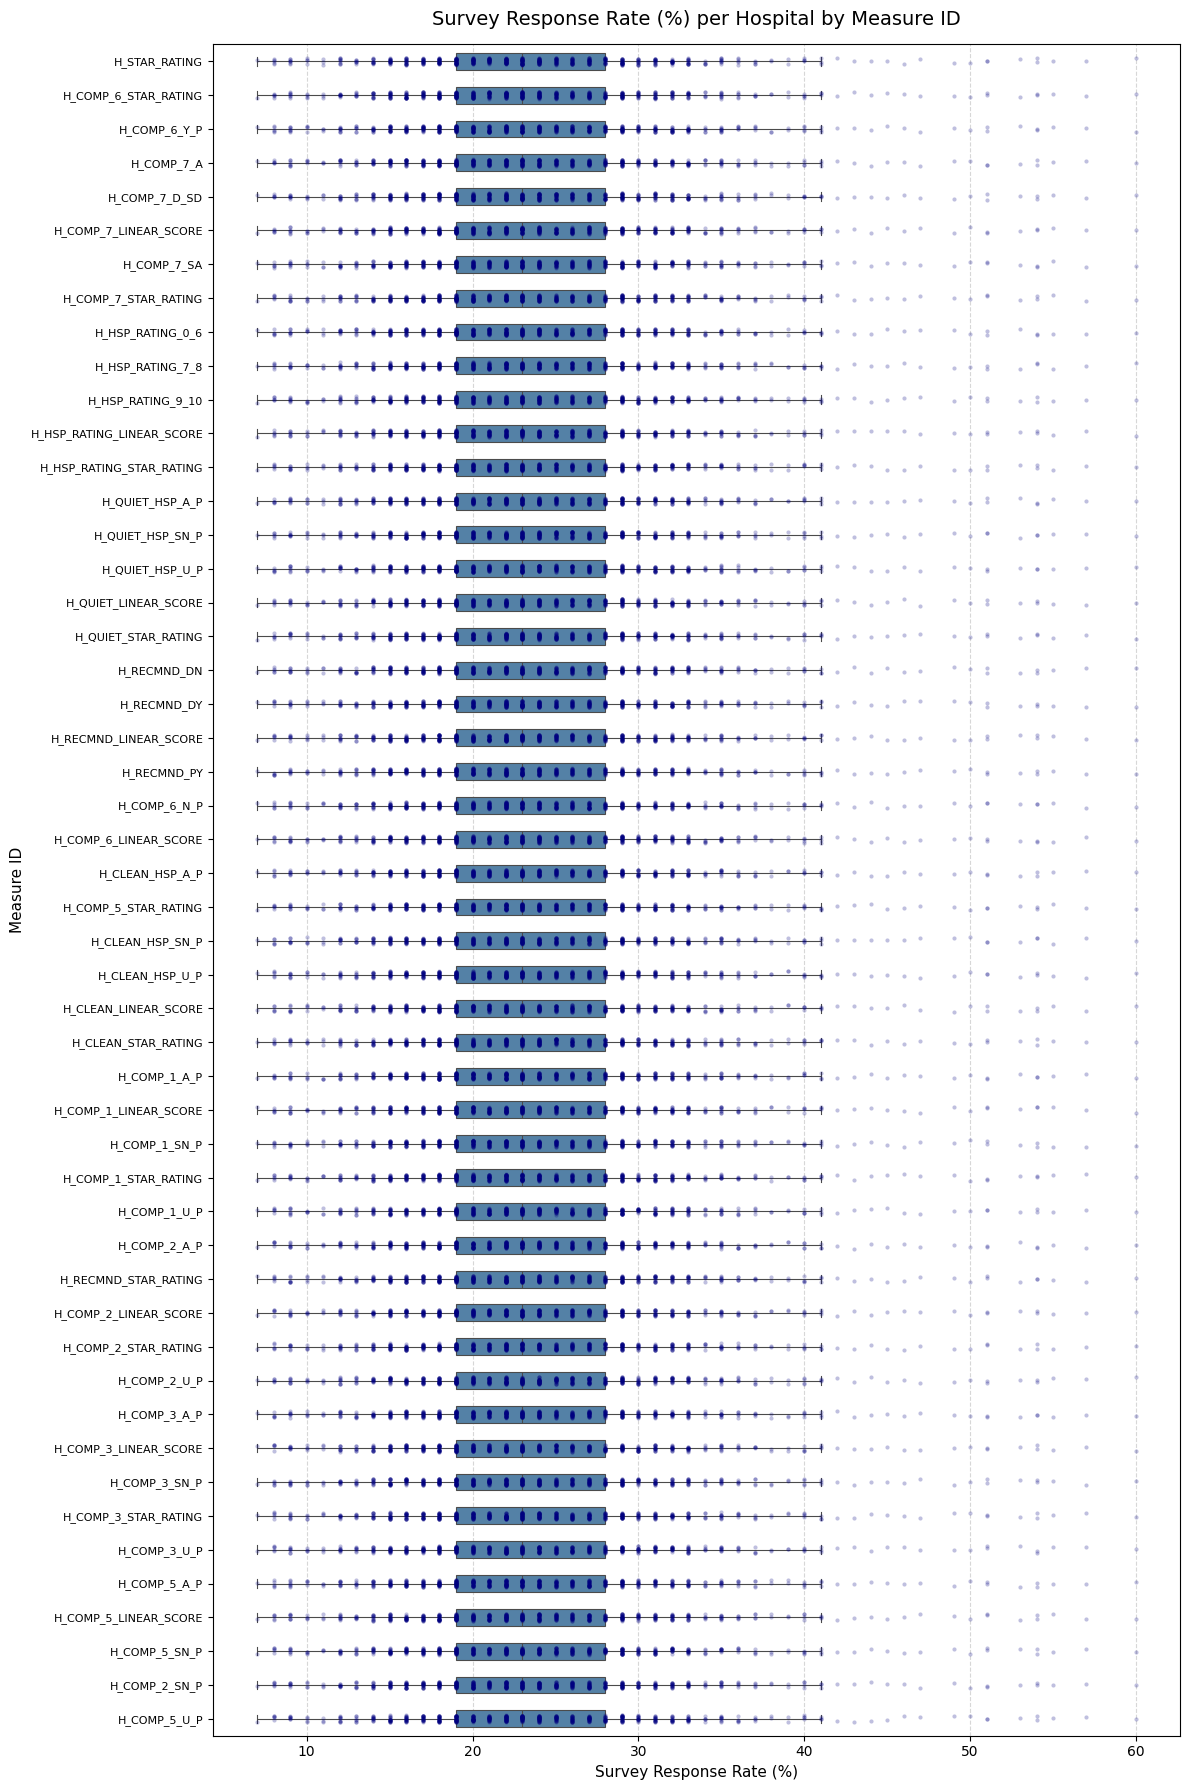

In [17]:
# ── Build per-hospital per-measure response rate table ────────────────────────
plot_df = (
    df_clean[['Measure ID', 'Provider ID', 'Hospital Name', 'Survey Response Rate Percent']]
    .dropna(subset=['Survey Response Rate Percent'])
    .drop_duplicates()
)

# Mean response rate per measure (used to order the y-axis)
measure_order = (
    plot_df.groupby('Measure ID')['Survey Response Rate Percent']
    .mean()
    .sort_values()
    .index.tolist()
)

# ── Summary table ─────────────────────────────────────────────────────────────
summary = (
    plot_df.groupby('Measure ID')['Survey Response Rate Percent']
    .agg(Hospitals='count', Mean='mean', Median='median', Min='min', Max='max')
    .round(1)
    .loc[measure_order]
)
print("Survey Response Rate (%) by Measure ID:")
print(summary.to_string())

# ── Plot: box + strip, Measure ID (y) vs Response Rate % (x) ─────────────────
fig, ax = plt.subplots(figsize=(12, 18))

# Box plot — shows distribution across hospitals per measure
sns.boxplot(
    data=plot_df,
    x='Survey Response Rate Percent',
    y='Measure ID',
    order=measure_order,
    color='steelblue',
    width=0.5,
    fliersize=0,          # hide fliers — shown by strip instead
    linewidth=0.8,
    ax=ax,
)

# Strip plot — each dot = one hospital
sns.stripplot(
    data=plot_df,
    x='Survey Response Rate Percent',
    y='Measure ID',
    order=measure_order,
    color='navy',
    alpha=0.25,
    size=3,
    jitter=True,
    ax=ax,
)

ax.set_title('Survey Response Rate (%) per Hospital by Measure ID', fontsize=14, pad=14)
ax.set_xlabel('Survey Response Rate (%)', fontsize=11)
ax.set_ylabel('Measure ID', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()